In [1]:
!git clone https://github.com/khanh06062007/yolov12.git

Cloning into 'yolov12'...
remote: Enumerating objects: 1093, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 1093 (delta 0), reused 0 (delta 0), pack-reused 1090 (from 1)
Receiving objects: 100% (1093/1093), 1.93 MiB | 10.85 MiB/s, done.
Resolving deltas: 100% (480/480), done.


In [2]:
%cd yolov12

/kaggle/working/yolov12


In [ ]:
%pip install -q -r requirements.txt
%pip install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/28

In [4]:
# Example for downloading yolov12n.pt if it's missing
!wget https://github.com/sunsmarterjie/yolov12/releases/download/turbo/yolov12n.pt

--2026-04-20 02:54:07--  https://github.com/sunsmarterjie/yolov12/releases/download/turbo/yolov12n.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/16347a3c-8fea-4ca8-a214-f01fc5e82318?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-20T03%3A50%3A18Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-20T02%3A49%3A27Z&ske=2026-04-20T03%3A50%3A18Z&sks=b&skv=2018-11-09&sig=fJ%2FJm5awhM2joqPBn54O%2B31kpIlaoOpKueGtUbyTc0s%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NjY1Mzk0OCwibmJmIjoxNzc2NjUzNjQ4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iL

In [5]:
%cd ..
!gdown 1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R
!mkdir safety_helmet_dataset
!unzip -q 'Safety_Helmet_Dataset.zip' -d 'safety_helmet_dataset'

/kaggle/working
Downloading...
From (original): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R
From (redirected): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R&confirm=t&uuid=f7d1a943-41eb-43e3-9751-5fc5c60bcd1d
To: /kaggle/working/Safety_Helmet_Dataset.zip
100%|██████████████████████████████████████| 33.7M/33.7M [00:00<00:00, 53.0MB/s]


In [6]:
%cd yolov12/

/kaggle/working/yolov12


In [7]:
import os
os.environ["TORCH_FORCE_WEIGHTS_ONLY_LOAD"] = "0"

from ultralytics import YOLO

# Khởi tạo model (nếu file .pt chưa có, nó sẽ tự tải về)
MODEL_PATH = 'yolov12n.pt'
model = YOLO(MODEL_PATH)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [8]:
model.info()

YOLOv12n summary: 497 layers, 2,553,904 parameters, 0 gradients, 6.2 GFLOPs


(497, 2553904, 0, 6.152204800000001)

In [9]:
YAML_PATH = '../safety_helmet_dataset/data.yaml'
EPOCHS = 13
IMG_SIZE = 640
BATCH_SIZE = 64

model.train(data=YAML_PATH,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            imgsz=IMG_SIZE)

New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.pt, data=../safety_helmet_dataset/data.yaml, epochs=13, time=None, patience=100, batch=64, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sa

100%|██████████| 755k/755k [00:00<00:00, 17.7MB/s]
E0000 00:00:1776653675.818403      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776653675.877686      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776653676.342688      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653676.342723      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653676.342727      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653676.342729      22 computation_placer.cc:177] comput

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2, 1, 4]          
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    174720  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

train: Scanning /kaggle/working/safety_helmet_dataset/train/labels... 761 images, 0 backgrounds, 0 corrupt: 100%|██████████| 761/761 [00:00<00:00, 1291.17it/s]


train: New cache created: /kaggle/working/safety_helmet_dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all        218        586      0.835      0.845      0.876      0.438



13 epochs completed in 0.068 hours.
Optimizer stripped from /kaggle/working/yolov12/runs/detect/train/weights/last.pt, 5.4MB
Optimizer stripped from /kaggle/working/yolov12/runs/detect/train/weights/best.pt, 5.4MB

Validating /kaggle/working/yolov12/runs/detect/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 376 layers, 2,508,929 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


                   all        218        586      0.835      0.845      0.877      0.436
                  head         18         27      0.851      0.741      0.813      0.333
                helmet        195        285      0.899      0.879      0.936      0.476
                person        155        274      0.754      0.916      0.882      0.498
Speed: 0.2ms preprocess, 5.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/yolov12/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798a54dc0290>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [10]:
TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
model = YOLO(TRAINED_MODEL_PATH)

model.val(data=YAML_PATH,
          imgsz=IMG_SIZE,
          split='test')

Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 376 layers, 2,508,929 parameters, 0 gradients, 5.8 GFLOPs


val: Scanning /kaggle/working/safety_helmet_dataset/test/labels... 109 images, 0 backgrounds, 0 corrupt: 100%|██████████| 109/109 [00:00<00:00, 1313.13it/s]

val: New cache created: /kaggle/working/safety_helmet_dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]


                   all        109        320      0.797      0.873      0.865      0.444
                  head         12         16      0.848      0.812      0.854      0.368
                helmet         98        162      0.879      0.937      0.947      0.502
                person         78        142      0.665      0.868      0.795      0.462
Speed: 0.3ms preprocess, 10.5ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to /kaggle/working/yolov12/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798a090e94c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /kaggle/working/safety_helmet_dataset/valid/images/helmet-100-_jpg.rf.4322c86f0efaff251b2d8d2f564c5b3d.jpg: 640x640 2 helmets, 2 persons, 13.3ms
Speed: 2.3ms preprocess, 13.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


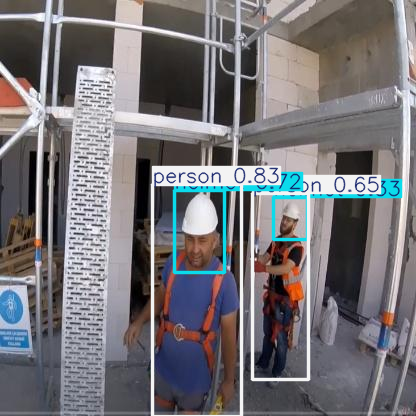

In [11]:
from PIL import Image
import cv2
from ultralytics import YOLO

TRAINED_MODEL_PATH = 'runs/detect/train/weights/best.pt'
model = YOLO(TRAINED_MODEL_PATH)
IMAGE_URL = '/kaggle/working/safety_helmet_dataset/valid/images/helmet-100-_jpg.rf.4322c86f0efaff251b2d8d2f564c5b3d.jpg'
img = cv2.imread(IMAGE_URL)
CONF_THRESHOLD = 0.3
IMG_SIZE = 640

results = model.predict(source=IMAGE_URL,
                       imgsz=IMG_SIZE,
                       conf=CONF_THRESHOLD)
annotated_img = results[0].plot()
img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Chuyển từ mảng numpy sang đối tượng ảnh PIL
display(Image.fromarray(img_rgb))
